# Gradient testing — convergent evidence from cross-sectional data

Secondary analyses building on `cross-sectional.ipynb`. Five tests organized per-prediction:

1. **Control LI characterization** — measure the categorical premise (asymmetric vs symmetric) in *this* sample's controls; compare to published values.
2. **Selectivity contrast preservation** — within-ROI rank order of category preference. *Implemented as RDM-based proxy* — see Section 4 caveat.
3. **Distinctiveness decomposition** — within- vs between-category similarity components. *Limited to between-category from current CSV* — see Section 5 caveat.
4. **Sub-ROI agreement** — sensitivity check: is each category-level disruption claim consistent across its sub-ROIs?
5. **Hemisphere-symmetric prediction (gradient rank correlation)** — single falsifiable test. Run at both 4-category and 10-sub-ROI granularity, on sum-selectivity *and* distinctiveness as co-primary measures.

Inputs are the same CSVs used by `cross-sectional.ipynb` — no re-extraction. All exclusions and session-selection rules match the primary notebook.

## 1. Setup

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import t as tdist, spearmanr
from matplotlib.lines import Line2D

sys.path.insert(0, '/user_data/csimmon2/git_repos/sym_pt')
from sym_pt_params import processed_dir

BASE    = Path(processed_dir)
LIU_CSV = Path('/user_data/csimmon2/git_repos/sym_pt/D_liu/liu_exact_replication_v2.csv')
FIG_DIR = Path('/user_data/csimmon2/git_repos/sym_pt/C_results/figures/gradient_testing')
FIG_DIR.mkdir(parents=True, exist_ok=True)

EXCLUDE     = ['sub-017']
EXCLUDE_SES = [('sub-108', 2)]

# Permutation parameters — match cross-sectional.ipynb conventions
N_PERM = 10000
SEED   = 42

plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans']
plt.rcParams.update({'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})

print(f'LIU_CSV : {LIU_CSV}')
print(f'FIG_DIR : {FIG_DIR}')

LIU_CSV : /user_data/csimmon2/git_repos/sym_pt/D_liu/liu_exact_replication_v2.csv
FIG_DIR : /user_data/csimmon2/git_repos/sym_pt/C_results/figures/gradient_testing


## 2. Load data

Mirrors the load logic in `cross-sectional.ipynb`: controls → first session, OTC patients → last session. NonOTC excluded from group comparisons.

In [2]:
le = pd.read_csv(LIU_CSV)
addon = LIU_CSV.parent / 'liu_exact_replication_v2_IFG_addon.csv'
if addon.exists():
    le = pd.concat([le, pd.read_csv(addon)], ignore_index=True)
    print(f'Merged IFG addon: +{(pd.read_csv(addon)["subject_id"]).nunique()} subj')
le = le[~le['subject_id'].isin(EXCLUDE)]
le['ses_num'] = pd.to_numeric(le['session'], errors='coerce').astype(int)
for bad_sub, bad_ses in EXCLUDE_SES:
    le = le[~((le['subject_id'] == bad_sub) & (le['ses_num'] == bad_ses))]

le_summary = le.drop(columns=['pair', 'fisher_r']).drop_duplicates().copy()

ctrl_all = le_summary[le_summary['status'] == 'control']
fs = ctrl_all.groupby('subject_id')['ses_num'].min().reset_index().rename(columns={'ses_num': 'keep'})
ctrl_le = ctrl_all.merge(fs, on='subject_id')
ctrl_le = ctrl_le[ctrl_le['ses_num'] == ctrl_le['keep']].drop(columns='keep')

pt_all = le_summary[le_summary['group'] == 'OTC']
ls = pt_all.groupby('subject_id')['ses_num'].max().reset_index().rename(columns={'ses_num': 'keep'})
pt_le = pt_all.merge(ls, on='subject_id')
pt_le = pt_le[pt_le['ses_num'] == pt_le['keep']].drop(columns='keep')

ctrl_pw = le[le['status'] == 'control'].merge(fs, on='subject_id')
ctrl_pw = ctrl_pw[ctrl_pw['ses_num'] == ctrl_pw['keep']].drop(columns='keep')
pt_pw = le[le['group'] == 'OTC'].merge(ls, on='subject_id')
pt_pw = pt_pw[pt_pw['ses_num'] == pt_pw['keep']].drop(columns='keep')

ctrl_subs = sorted(ctrl_le['subject_id'].unique())
otc_subs  = sorted(pt_le['subject_id'].unique())

print(f'Controls: {len(ctrl_subs)}')
print(f'OTC patients: {len(otc_subs)}')
print(f'  LH-intact: {sum(pt_le.drop_duplicates("subject_id")["intact_hemi"]=="left")}')
print(f'  RH-intact: {sum(pt_le.drop_duplicates("subject_id")["intact_hemi"]=="right")}')

Controls: 38
OTC patients: 22
  LH-intact: 11
  RH-intact: 11


## 3. Helpers

In [3]:
# Sub-ROI structure. word_IFG present only if addon was loaded.
CAT_SUBROIS = {
    'face':   ['face_FFA', 'face_STS'],
    'house':  ['house_PPA', 'house_TOS'],
    'object': ['object_LOC', 'object_pF'],
    'word':   ['word_VWFA', 'word_STG', 'word_pSTG_liu', 'word_IFG'],
}
CATS4 = ['face', 'object', 'house', 'word']
CAT_COLOR = {'face': '#cc0066', 'house': '#009900', 'object': '#0077cc', 'word': '#ff8800'}

# Filter sub-ROI lists to those actually present in data
_present = set(le_summary['category'].unique())
CAT_SUBROIS = {c: [r for r in rs if r in _present] for c, rs in CAT_SUBROIS.items()}
ALL_SUBROIS = [r for rs in CAT_SUBROIS.values() for r in rs]
print('Sub-ROIs available:')
for c, rs in CAT_SUBROIS.items():
    print(f'  {c}: {rs}')

def crawford(x, c):
    """Crawford & Howell (1998) modified t, returns (t, p)."""
    c = np.asarray(c); c = c[~np.isnan(c)]
    if len(c) < 3 or np.isnan(x): return np.nan, np.nan
    m, sd = c.mean(), c.std(ddof=1)
    if sd == 0: return np.nan, np.nan
    t = (x - m) / (sd * np.sqrt((len(c) + 1) / len(c)))
    p = 2 * (1 - tdist.cdf(abs(t), df=len(c) - 1))
    return t, p

def fisher_z(r):
    r = np.clip(np.asarray(r, float), -0.9999, 0.9999)
    return 0.5 * np.log((1 + r) / (1 - r))

def pt_intact_hemi(sub):
    sd = pt_le[pt_le['subject_id'] == sub]
    if sd.empty: return None
    intact = sd['intact_hemi'].iloc[0]
    return 'l' if intact == 'left' else 'r' if intact == 'right' else None

def perm_diff_p(ctrl_vals, pt_vals, n_perm=N_PERM, seed=SEED):
    """Two-sided permutation p for mean(pt) - mean(ctrl)."""
    ctrl_vals = np.asarray(ctrl_vals, float); ctrl_vals = ctrl_vals[~np.isnan(ctrl_vals)]
    pt_vals   = np.asarray(pt_vals,   float); pt_vals   = pt_vals[~np.isnan(pt_vals)]
    if len(ctrl_vals) < 3 or len(pt_vals) < 2:
        return np.nan, np.nan
    obs = pt_vals.mean() - ctrl_vals.mean()
    pool = np.concatenate([ctrl_vals, pt_vals])
    n_pt = len(pt_vals)
    rng = np.random.RandomState(seed)
    null = np.empty(n_perm)
    for i in range(n_perm):
        perm = rng.permutation(pool)
        null[i] = perm[:n_pt].mean() - perm[n_pt:].mean()
    p = (np.abs(null) >= abs(obs)).mean()
    return obs, p

def get_subj_value(df, sub, roi, hemi, col):
    m = df[(df['subject_id']==sub) & (df['category']==roi) & (df['hemi']==hemi)]
    return m[col].iloc[0] if len(m) else np.nan

Sub-ROIs available:
  face: ['face_FFA', 'face_STS']
  house: ['house_PPA', 'house_TOS']
  object: ['object_LOC', 'object_pF']
  word: ['word_VWFA', 'word_STG', 'word_pSTG_liu', 'word_IFG']


## 4. Proposal 1 — Control lateralization-index characterization

Establishes that the categorical premise ("face/word asymmetric, house/object symmetric") is a **measured property of this sample's controls**, not an a-priori stipulation.

**LI convention:** $LI = (L - R) / (L + R)$ on `sum_selec_norm`, computed per subject, after collapsing sub-ROIs by mean within hemisphere. Positive LI = left-lateralized; negative = right-lateralized; near-zero = symmetric.

**Reported values for comparison are placeholders.** Replace `LIT_VALUES` with extracted numbers from Behrmann & Plaut 2020 / Nordt 2023 before paper inclusion. The Nordt sample is developmental (5–12 yr); our control range diverges — caveat explicitly.

In [4]:
# --- Per-subject category-level LI (controls only) ---
def subject_category_li(df, subject, category):
    """LI = (L - R) / (L + R) using mean sum_selec_norm across sub-ROIs at each hemi."""
    rois = CAT_SUBROIS[category]
    sd = df[(df['subject_id']==subject) & (df['category'].isin(rois))]
    L = sd[sd['hemi']=='l']['sum_selec_norm'].dropna()
    R = sd[sd['hemi']=='r']['sum_selec_norm'].dropna()
    L = L[L > 0]; R = R[R > 0]
    if len(L) == 0 or len(R) == 0:
        return np.nan
    Lm, Rm = L.mean(), R.mean()
    if (Lm + Rm) == 0:
        return np.nan
    return (Lm - Rm) / (Lm + Rm)

rows = []
for s in ctrl_subs:
    for cat in CATS4:
        rows.append({'subject_id': s, 'category': cat, 'LI': subject_category_li(ctrl_le, s, cat)})
li_df = pd.DataFrame(rows)

# Summary by category
print(f'{"Category":10s} {"N":>4s} {"Mean LI":>10s} {"SD":>8s} {"Median":>8s} {"% L-lat":>8s} {"% R-lat":>8s}')
print('-' * 60)
li_summary_rows = []
for cat in CATS4:
    vals = li_df[li_df['category']==cat]['LI'].dropna().values
    pct_L = (vals > 0.10).mean() * 100  # threshold for "clearly lateralized"
    pct_R = (vals < -0.10).mean() * 100
    li_summary_rows.append({'category': cat, 'n': len(vals), 'mean': vals.mean(),
                            'sd': vals.std(ddof=1), 'median': np.median(vals),
                            'pct_left': pct_L, 'pct_right': pct_R})
    print(f'{cat:10s} {len(vals):>4d} {vals.mean():>+10.3f} {vals.std(ddof=1):>8.3f} '
          f'{np.median(vals):>+8.3f} {pct_L:>7.0f}% {pct_R:>7.0f}%')
li_summary = pd.DataFrame(li_summary_rows)

Category      N    Mean LI       SD   Median  % L-lat  % R-lat
------------------------------------------------------------
face         38     -0.235    0.400   -0.246      16%      68%
object       38     +0.077    0.160   +0.089      45%      11%
house        38     -0.133    0.224   -0.160      11%      61%
word         36     +0.097    0.367   +0.120      56%      31%


In [5]:
# --- Compare to published values ---
# REPLACE THESE PLACEHOLDERS with actual literature values before paper inclusion.
# Behrmann & Plaut 2020: adult LIs for category-selective regions
# Nordt 2023: developmental (5-12 yr) LIs — caveat age mismatch
LIT_VALUES = {
    # category: {'source': mean_LI}   (positive = L-lateralized)
    'face':   {'Behrmann_Plaut_2020': None, 'Nordt_2023': None},  # expected: negative (R-lat)
    'word':   {'Behrmann_Plaut_2020': None, 'Nordt_2023': None},  # expected: positive (L-lat)
    'house':  {'Behrmann_Plaut_2020': None, 'Nordt_2023': None},  # expected: ~0 (bilateral)
    'object': {'Behrmann_Plaut_2020': None, 'Nordt_2023': None},  # expected: ~0 (bilateral)
}
print('LIT_VALUES is a placeholder — fill in mean LIs from Behrmann & Plaut 2020 and Nordt 2023')
print('before paper inclusion. Below: this-sample LI vs (placeholder) literature.\n')
print(f'{"Category":10s} {"This sample":>14s} {"B&P 2020":>12s} {"Nordt 2023":>14s}')
print('-' * 56)
for cat in CATS4:
    s = li_summary[li_summary['category']==cat].iloc[0]
    bp = LIT_VALUES[cat]['Behrmann_Plaut_2020']
    no = LIT_VALUES[cat]['Nordt_2023']
    bp_s = f'{bp:+.3f}' if bp is not None else '—'
    no_s = f'{no:+.3f}' if no is not None else '—'
    print(f'{cat:10s} {s["mean"]:>+8.3f} ± {s["sd"]:.3f} {bp_s:>12s} {no_s:>14s}')
print('\nCaveat: Nordt et al. 2023 sample is developmental (5–12 yr). Our control range '
      'differs — note in any direct numeric comparison.')

LIT_VALUES is a placeholder — fill in mean LIs from Behrmann & Plaut 2020 and Nordt 2023
before paper inclusion. Below: this-sample LI vs (placeholder) literature.

Category      This sample     B&P 2020     Nordt 2023
--------------------------------------------------------
face         -0.235 ± 0.400            —              —
object       +0.077 ± 0.160            —              —
house        -0.133 ± 0.224            —              —
word         +0.097 ± 0.367            —              —

Caveat: Nordt et al. 2023 sample is developmental (5–12 yr). Our control range differs — note in any direct numeric comparison.


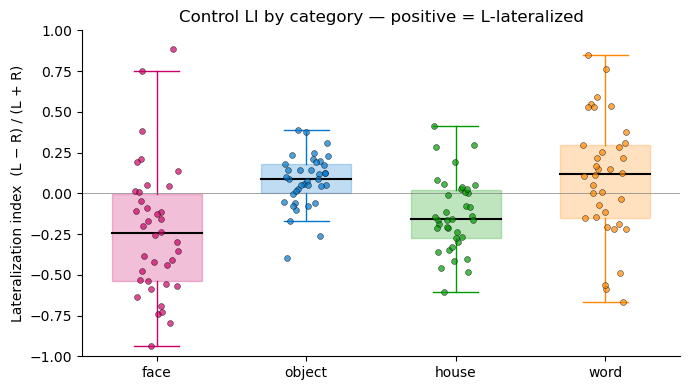

Saved: /user_data/csimmon2/git_repos/sym_pt/C_results/figures/gradient_testing/control_LI_per_subject.csv


In [6]:
# --- LI distribution figure ---
fig, ax = plt.subplots(figsize=(7, 4))
RNG = np.random.RandomState(SEED)
for xi, cat in enumerate(CATS4):
    vals = li_df[li_df['category']==cat]['LI'].dropna().values
    color = CAT_COLOR[cat]
    ax.boxplot(vals, positions=[xi], widths=0.6, patch_artist=True, showfliers=False,
               medianprops={'color':'black', 'lw':1.5},
               whiskerprops={'color':color}, capprops={'color':color},
               boxprops={'facecolor':color, 'alpha':0.25, 'edgecolor':color})
    ax.scatter(xi + RNG.uniform(-0.15, 0.15, len(vals)), vals,
               s=18, color=color, alpha=0.7, edgecolors='black', linewidth=0.4, zorder=5)
ax.axhline(0, color='gray', lw=0.5)
ax.set_xticks(range(len(CATS4)))
ax.set_xticklabels(CATS4)
ax.set_ylabel('Lateralization index  (L − R) / (L + R)')
ax.set_title('Control LI by category — positive = L-lateralized')
ax.set_ylim(-1, 1)
plt.tight_layout()
plt.savefig(FIG_DIR / 'control_LI_by_category.png', dpi=200, bbox_inches='tight')
plt.show()
li_df.to_csv(FIG_DIR / 'control_LI_per_subject.csv', index=False)
print(f'Saved: {FIG_DIR / "control_LI_per_subject.csv"}')

## 5. Proposal 3 — Selectivity contrast preservation (RDM-based proxy)

**Caveat: this is a proxy, not the literal rank-order test.** The original prediction ("in word_VWFA, do patients still show word > face > object > house" on response magnitude) requires per-condition betas extracted within each ROI mask, which are not in `liu_exact_replication_v2.csv`. Implementing it would need a new pipeline pass over the cope volumes.

**Proxy used here:** for each ROI, rank the 4 categories by *mean dissimilarity from the other three* (computed from off-diagonal `fisher_r`). The category most distinct from the others is the "preferred" category by this measure. We then ask whether the preferred-category rank in each patient matches the modal control rank for that ROI, and whether the full rank profile is preserved (Spearman ρ vs control mean profile).

*This tests rank-order of pattern distinctness, not response magnitude.* The two are related but not identical — note this when interpreting.

In [9]:
def category_distinctness_profile(pw_df, subject, roi, hemi):
    """For one subject/ROI/hemi: compute mean dissimilarity (1 - r) from each category
    to the other three. Returns dict {face, object, house, word: mean dissim} or None."""
    sd = pw_df[(pw_df['subject_id']==subject) &
               (pw_df['category']==roi) & (pw_df['hemi']==hemi)]
    if len(sd) < 6:
        return None
    profile = {}
    for cat in CATS4:
        rs = []
        for other in CATS4:
            if other == cat: continue
            hit = sd[sd['pair'].isin([f'{cat}-{other}', f'{other}-{cat}'])]
            if len(hit):
                fr = hit['fisher_r'].iloc[0]
                if not np.isnan(fr):
                    rs.append(np.tanh(fr))
        if len(rs) != 3:
            return None
        profile[cat] = 1.0 - np.mean(rs)
    if any(np.isnan(v) for v in profile.values()):
        return None
    return profile

# Build profile DataFrame for all subj × ROI × hemi combos (controls + patients)
ROIS_PW = ALL_SUBROIS  # all sub-ROIs have pairwise data
rows = []
for df, status, subs in [(ctrl_pw, 'control', ctrl_subs), (pt_pw, 'patient', otc_subs)]:
    for s in subs:
        for roi in ROIS_PW:
            for h in ('l', 'r'):
                prof = category_distinctness_profile(df, s, roi, h)
                if prof is None: continue
                row = {'subject_id': s, 'status': status, 'roi': roi, 'hemi': h}
                row.update({f'd_{c}': prof[c] for c in CATS4})
                # rank: 1 = most distinct (preferred)
                ranks = pd.Series({c: prof[c] for c in CATS4}).rank(ascending=False, method='min')
                row.update({f'rank_{c}': int(ranks[c]) for c in CATS4})
                rows.append(row)
profile_df = pd.DataFrame(rows)
print(f'Profiles built: {len(profile_df)} subj×ROI×hemi rows')
print(profile_df['status'].value_counts())

Profiles built: 976 subj×ROI×hemi rows
control    756
patient    220
Name: status, dtype: int64


In [10]:
# --- Modal control rank profile per ROI × hemi, and patient agreement ---
# For each ROI × hemi: get mean control distinctness profile, rank it.
# Then for each patient at that ROI × intact_hemi, compute Spearman ρ vs control profile.
ROI_PRIMARY = {  # the canonical preferred category for each ROI (from neuroanatomy literature)
    'face_FFA': 'face', 'face_STS': 'face',
    'house_PPA': 'house', 'house_TOS': 'house',
    'object_LOC': 'object', 'object_pF': 'object',
    'word_VWFA': 'word', 'word_STG': 'word', 'word_pSTG_liu': 'word', 'word_IFG': 'word',
}

rows = []
for roi in ROIS_PW:
    for h in ('l', 'r'):
        ctrl_sub = profile_df[(profile_df['status']=='control') & (profile_df['roi']==roi) & (profile_df['hemi']==h)]
        if len(ctrl_sub) < 3: continue
        ctrl_profile = ctrl_sub[[f'd_{c}' for c in CATS4]].mean().values
        ctrl_ranks = pd.Series(dict(zip(CATS4, ctrl_profile))).rank(ascending=False, method='min')
        ctrl_top = CATS4[int(np.argmax(ctrl_profile))]
        # control internal consistency: mean Spearman of each control vs leave-one-out mean
        ctrl_consistency = []
        for _, r in ctrl_sub.iterrows():
            this_prof = np.array([r[f'd_{c}'] for c in CATS4])
            others = ctrl_sub[ctrl_sub['subject_id'] != r['subject_id']][[f'd_{c}' for c in CATS4]].mean().values
            rho, _ = spearmanr(this_prof, others)
            ctrl_consistency.append(rho)
        # patient values: only at intact hemi matching h
        pt_sub = profile_df[(profile_df['status']=='patient') & (profile_df['roi']==roi) & (profile_df['hemi']==h)]
        # restrict to patients whose intact hemi == h
        pt_sub = pt_sub[pt_sub['subject_id'].apply(lambda s: pt_intact_hemi(s) == h)]
        for _, r in pt_sub.iterrows():
            this_prof = np.array([r[f'd_{c}'] for c in CATS4])
            rho, _ = spearmanr(this_prof, ctrl_profile)
            pt_top = CATS4[int(np.argmax(this_prof))]
            top_match = (pt_top == ctrl_top)
            primary_match = (pt_top == ROI_PRIMARY.get(roi))
            rows.append({'subject_id': r['subject_id'], 'roi': roi, 'hemi': h,
                         'ctrl_top': ctrl_top, 'pt_top': pt_top,
                         'top_matches_ctrl': top_match,
                         'top_matches_canonical': primary_match,
                         'rho_vs_ctrl_mean': rho,
                         'ctrl_internal_rho': np.mean(ctrl_consistency)})
rank_pres = pd.DataFrame(rows)
print(f'Patient × ROI × hemi rows: {len(rank_pres)}')
print('\nCanonical preferred-category match rate (intact hemi only):')
for roi in ROIS_PW:
    sub = rank_pres[rank_pres['roi']==roi]
    if not len(sub): continue
    print(f'  {roi:18s} n={len(sub):2d}  ctrl_top_match={sub["top_matches_ctrl"].mean():.0%}  '
          f'canonical_match={sub["top_matches_canonical"].mean():.0%}  '
          f'mean ρ={sub["rho_vs_ctrl_mean"].mean():+.3f}  '
          f'(ctrl internal ρ={sub["ctrl_internal_rho"].iloc[0]:+.3f})')

Patient × ROI × hemi rows: 220

Canonical preferred-category match rate (intact hemi only):
  face_FFA           n=22  ctrl_top_match=14%  canonical_match=45%  mean ρ=+0.309  (ctrl internal ρ=+0.200)
  face_STS           n=22  ctrl_top_match=27%  canonical_match=36%  mean ρ=-0.155  (ctrl internal ρ=+0.111)
  house_PPA          n=22  ctrl_top_match=41%  canonical_match=41%  mean ρ=+0.382  (ctrl internal ρ=+0.389)
  house_TOS          n=22  ctrl_top_match=45%  canonical_match=45%  mean ρ=+0.364  (ctrl internal ρ=+0.621)
  object_LOC         n=22  ctrl_top_match=23%  canonical_match=5%  mean ρ=-0.009  (ctrl internal ρ=+0.189)
  object_pF          n=22  ctrl_top_match=32%  canonical_match=5%  mean ρ=+0.364  (ctrl internal ρ=+0.484)
  word_VWFA          n=22  ctrl_top_match=41%  canonical_match=18%  mean ρ=+0.364  (ctrl internal ρ=+0.589)
  word_STG           n=22  ctrl_top_match=59%  canonical_match=59%  mean ρ=+0.318  (ctrl internal ρ=+0.200)
  word_pSTG_liu      n=22  ctrl_top_match=50% 

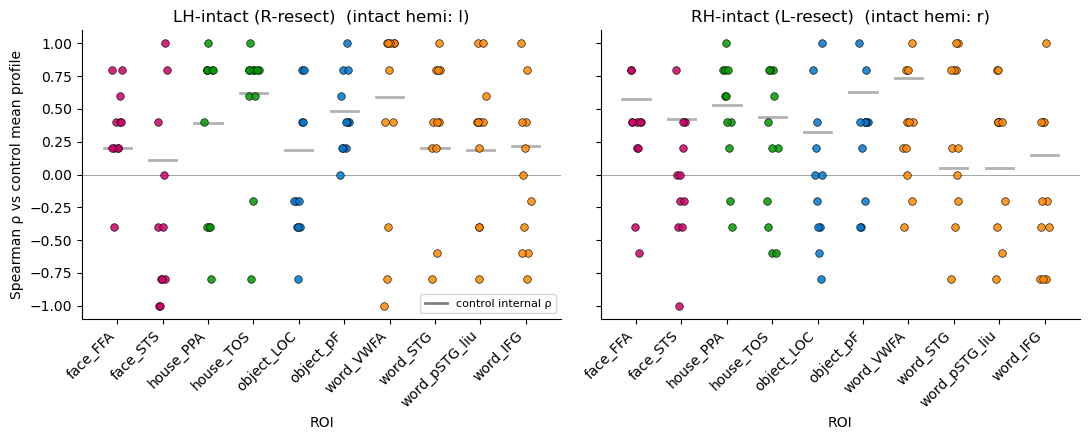

In [11]:
# --- Per-patient Spearman ρ vs control mean profile, by side and ROI ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, intact, label in zip(axes, ['l', 'r'], ['LH-intact (R-resect)', 'RH-intact (L-resect)']):
    rois_present = [r for r in ROIS_PW if (rank_pres[(rank_pres['roi']==r) & (rank_pres['hemi']==intact)].shape[0] > 0)]
    for xi, roi in enumerate(rois_present):
        sub = rank_pres[(rank_pres['roi']==roi) & (rank_pres['hemi']==intact)]
        if not len(sub): continue
        cat = roi.split('_')[0]
        ax.scatter([xi]*len(sub) + np.random.RandomState(SEED+xi).uniform(-0.12, 0.12, len(sub)),
                   sub['rho_vs_ctrl_mean'].values, s=30, color=CAT_COLOR[cat],
                   alpha=0.85, edgecolors='black', linewidth=0.5, zorder=5)
        # control internal consistency band
        ax.plot([xi-0.3, xi+0.3], [sub['ctrl_internal_rho'].iloc[0]]*2, color='gray', lw=2, alpha=0.6)
    ax.set_xticks(range(len(rois_present)))
    ax.set_xticklabels(rois_present, rotation=45, ha='right')
    ax.axhline(0, color='gray', lw=0.5)
    ax.set_title(f'{label}  (intact hemi: {intact})')
    ax.set_xlabel('ROI')
axes[0].set_ylabel('Spearman ρ vs control mean profile')
axes[0].legend([Line2D([0],[0], color='gray', lw=2)], ['control internal ρ'], loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / 'rank_preservation_proxy.png', dpi=200, bbox_inches='tight')
plt.show()
rank_pres.to_csv(FIG_DIR / 'rank_preservation_proxy.csv', index=False)

## 6. Proposal 4 — Distinctiveness decomposition (partial)

**Limitation:** Liu's `liu_distinctiveness` is computed from split-half pattern correlations — within-category (same-category split halves) minus between-category (different-category pairs), Fisher-z transformed. The current `liu_exact_replication_v2.csv` stores only the scalar `liu_distinctiveness` and *between-category* pairwise correlations (`fisher_r` per `pair`). The within-category split-half values are not in the merged CSV.

**What we do here:**
1. Try to load `pairwise_correlations_*.csv` from `/group_results/liu_distinctiveness/` — if it contains within-category values, decompose properly.
2. If unavailable, compute a **between-category-only** decomposition: for each ROI's *preferred* category, split the 6 between-category pairs into (preferred-vs-others) and (non-preferred-vs-non-preferred). Compare these two components in patients vs controls.

Approach #2 is a partial decomposition — it tests whether the *contrast* between preferred and non-preferred pairs is preserved, but cannot separate "representations becoming noisier" from "categories blurring" cleanly. Flag this limitation in any paper text.

In [12]:
# --- Try to load proper within/between decomposition ---
# Adjust paths if needed for your cluster setup
GROUP_DIR = Path('/user_data/csimmon2/sym_pt/group_results/liu_distinctiveness')
candidate_files = list(GROUP_DIR.glob('pairwise_correlations_*.csv')) if GROUP_DIR.exists() else []
print(f'Candidate within/between files in {GROUP_DIR}:')
for f in candidate_files:
    print(f'  {f.name}')
if not candidate_files:
    print('  none found — falling back to between-category-only decomposition.')

decomp_within_available = False
if candidate_files:
    # Inspect first file to check schema
    test = pd.read_csv(candidate_files[0])
    print(f'\nColumns in {candidate_files[0].name}: {list(test.columns)}')
    # Look for a column indicating within vs between
    if 'pair_type' in test.columns or 'within' in test.columns or any('within' in c.lower() for c in test.columns):
        decomp_within_available = True
        print('  Within-category data appears available — proper decomposition possible.')
        print('  TODO: code path for proper decomposition not implemented in this version.')
        print('        Inspect schema and add cell to compute within - between per ROI per subject.')
    else:
        print('  Schema does not appear to contain within-category values.')

Candidate within/between files in /user_data/csimmon2/sym_pt/group_results/liu_distinctiveness:
  pairwise_correlations_differential_pre_word13.csv
  pairwise_correlations_differential.csv
  pairwise_correlations_hybrid.csv
  pairwise_correlations_cat_vs_scramble.csv

Columns in pairwise_correlations_differential_pre_word13.csv: ['subject', 'subject_id', 'group', 'status', 'surgery_side', 'session', 'hemi', 'hemi_label', 'category', 'cat_type', 'roi_status', 'cope_set', 'pair', 'fisher_r']
  Schema does not appear to contain within-category values.


In [13]:
# --- Between-category partial decomposition: TWO PREFERENCE DEFINITIONS ---
# (A) Hardcoded ROI_PRIMARY (canonical from anatomy/labels)
# (B) Empirical: derived from control mean distinctness profile in this sample
# Run both, compare. Note: (B) risks circularity if used as primary; (A) is the
# defensible primary, (B) is sensitivity check.

# --- (A) hardcoded canonical preferred category ---
ROI_PRIMARY_HARDCODED = {
    'face_FFA': 'face', 'face_STS': 'face',
    'house_PPA': 'house', 'house_TOS': 'house',
    'object_LOC': 'object', 'object_pF': 'object',
    'word_VWFA': 'word', 'word_STG': 'word', 'word_pSTG_liu': 'word', 'word_IFG': 'word',
}

# --- (B) empirical preferred category from control mean profile ---
# Use the profile_df built in Section 5: argmax of mean control distinctness per ROI x hemi.
# We pick a single preferred category per ROI by averaging across both hemispheres in controls
# (so the same preferred cat is used regardless of hemi being analyzed).
ROI_PRIMARY_EMPIRICAL = {}
for roi in ROIS_PW:
    ctrl_sub = profile_df[(profile_df['status']=='control') & (profile_df['roi']==roi)]
    if len(ctrl_sub) < 3:
        ROI_PRIMARY_EMPIRICAL[roi] = ROI_PRIMARY_HARDCODED.get(roi)
        continue
    mean_d = ctrl_sub[[f'd_{c}' for c in CATS4]].mean().values
    ROI_PRIMARY_EMPIRICAL[roi] = CATS4[int(np.argmax(mean_d))]

print('Preferred-category mapping comparison:')
print(f'{"ROI":18s} {"hardcoded":>12s} {"empirical":>12s} {"match":>8s}')
print('-' * 54)
for roi in ROIS_PW:
    a = ROI_PRIMARY_HARDCODED.get(roi)
    b = ROI_PRIMARY_EMPIRICAL.get(roi)
    print(f'{roi:18s} {a:>12s} {b:>12s} {"✓" if a==b else "✗":>8s}')

def preferred_nonpreferred_dissim(pw_df, subject, roi, hemi, mapping):
    """Returns (mean dissim of pairs involving preferred cat, mean dissim of pairs among others)."""
    pref = mapping.get(roi)
    if pref is None: return np.nan, np.nan
    sd = pw_df[(pw_df['subject_id']==subject) & (pw_df['category']==roi) & (pw_df['hemi']==hemi)]
    if len(sd) < 6: return np.nan, np.nan
    pref_d, other_d = [], []
    for _, row in sd.iterrows():
        a, b = row['pair'].split('-')
        d = 1.0 - np.tanh(row['fisher_r'])
        if pref in (a, b):
            pref_d.append(d)
        else:
            other_d.append(d)
    if len(pref_d) != 3 or len(other_d) != 3:
        return np.nan, np.nan
    return np.mean(pref_d), np.mean(other_d)

def build_decomp(mapping):
    rows = []
    for df, status, subs in [(ctrl_pw, 'control', ctrl_subs), (pt_pw, 'patient', otc_subs)]:
        for s in subs:
            for roi in ROIS_PW:
                for h in ('l', 'r'):
                    pd_, od = preferred_nonpreferred_dissim(df, s, roi, h, mapping)
                    if np.isnan(pd_): continue
                    rows.append({'subject_id': s, 'status': status, 'roi': roi, 'hemi': h,
                                 'pref_dissim': pd_, 'other_dissim': od,
                                 'contrast': pd_ - od})
    return pd.DataFrame(rows)

def run_decomp_perm(decomp_df, label_tag):
    out = []
    for intact, label in [('l', 'LH (R-res)'), ('r', 'RH (L-res)')]:
        pt_subs_h = [s for s in otc_subs if pt_intact_hemi(s) == intact]
        for roi in ROIS_PW:
            ct = decomp_df[(decomp_df['status']=='control') & (decomp_df['roi']==roi) & (decomp_df['hemi']==intact)]
            pt = decomp_df[(decomp_df['status']=='patient') & (decomp_df['roi']==roi) & (decomp_df['hemi']==intact) &
                           (decomp_df['subject_id'].isin(pt_subs_h))]
            if len(ct) < 3 or len(pt) < 2: continue
            d_p, p_p = perm_diff_p(ct['pref_dissim'], pt['pref_dissim'])
            d_o, p_o = perm_diff_p(ct['other_dissim'], pt['other_dissim'])
            d_c, p_c = perm_diff_p(ct['contrast'], pt['contrast'])
            out.append({'mapping': label_tag, 'roi': roi, 'side': label,
                        'd_pref': d_p, 'p_pref': p_p,
                        'd_other': d_o, 'p_other': p_o,
                        'd_contrast': d_c, 'p_contrast': p_c})
    return pd.DataFrame(out)

decomp_A = build_decomp(ROI_PRIMARY_HARDCODED)
decomp_B = build_decomp(ROI_PRIMARY_EMPIRICAL)
res_A = run_decomp_perm(decomp_A, 'hardcoded')
res_B = run_decomp_perm(decomp_B, 'empirical')

for tag, res in [('HARDCODED (primary)', res_A), ('EMPIRICAL (sensitivity)', res_B)]:
    print(f'\n=== {tag} ===')
    print(f'{"ROI":18s} {"Side":18s} {"Δpref":>10s} {"p":>7s}  {"Δother":>10s} {"p":>7s}  {"Δcontrast":>10s} {"p":>7s}')
    print('-' * 90)
    for _, r in res.iterrows():
        flag = '*' if r['p_contrast'] < 0.05 else ('†' if r['p_contrast'] < 0.1 else '')
        print(f'{r["roi"]:18s} {r["side"]:18s} {r["d_pref"]:>+10.3f} {r["p_pref"]:>7.4f}  '
              f'{r["d_other"]:>+10.3f} {r["p_other"]:>7.4f}  {r["d_contrast"]:>+10.3f} {r["p_contrast"]:>7.4f} {flag}')

# Concordance check: do the two mappings give same sign on Δcontrast?
merged = res_A.merge(res_B, on=['roi', 'side'], suffixes=('_A', '_B'))
concord = ((merged['d_contrast_A'] > 0) == (merged['d_contrast_B'] > 0)).mean()
print(f'\nSign concordance on Δcontrast across mappings: {concord:.0%}')
print('Disagreements:')
disagree = merged[(merged['d_contrast_A'] > 0) != (merged['d_contrast_B'] > 0)]
for _, r in disagree.iterrows():
    print(f'  {r["roi"]:18s} {r["side"]:18s}  hardcoded={r["d_contrast_A"]:+.3f} empirical={r["d_contrast_B"]:+.3f}')

pd.concat([res_A, res_B]).to_csv(FIG_DIR / 'decomposition_partial.csv', index=False)
print(f'\nSaved: {FIG_DIR / "decomposition_partial.csv"}')
print('\nInterpretation:')
print('  Δpref < 0   = preferred-category pairs less dissimilar (preferred blurring with others)')
print('  Δother > 0  = non-preferred pairs more dissimilar (other categories spreading apart)')
print('  Δcontrast < 0 = narrowing of preferred-vs-other contrast (loss of selective structure)')
print('Use HARDCODED as primary; EMPIRICAL is sensitivity check (risks circularity).')

Preferred-category mapping comparison:
ROI                   hardcoded    empirical    match
------------------------------------------------------
face_FFA                   face         word        ✗
face_STS                   face         face        ✓
house_PPA                 house        house        ✓
house_TOS                 house        house        ✓
object_LOC               object         word        ✗
object_pF                object         word        ✗
word_VWFA                  word        house        ✗
word_STG                   word         word        ✓
word_pSTG_liu              word         word        ✓
word_IFG                   word         word        ✓

=== HARDCODED (primary) ===
ROI                Side                    Δpref       p      Δother       p   Δcontrast       p
------------------------------------------------------------------------------------------
face_FFA           LH (R-res)             +0.064  0.4277      -0.012  0.9011      +0.075  0.303

## 7. Proposal 5 — Sub-ROI agreement

Sensitivity check on category-level claims. For each category × group, compute Δ (patient mean − control mean) at each sub-ROI for two measures:
- log₁₀ `sum_selec_norm`
- `liu_distinctiveness`

Report whether all sub-ROIs in a category share the same sign of Δ (category claim supported) or whether one sub-ROI carries the effect (claim narrows). This is what addresses the "is this driven by one ROI" reviewer concern.

In [14]:
def collect_subj_vals(df, subjects, roi, hemi, col, log10=False):
    vals = []
    for s in subjects:
        v = get_subj_value(df, s, roi, hemi, col)
        if log10:
            if not (np.isnan(v)) and v > 0:
                vals.append(np.log10(v))
        else:
            if not np.isnan(v):
                vals.append(v)
    return np.array(vals)

agreement_rows = []
for intact, label in [('l', 'LH (R-res)'), ('r', 'RH (L-res)')]:
    pt_subs_h = [s for s in otc_subs if pt_intact_hemi(s) == intact]
    for cat in CATS4:
        for roi in CAT_SUBROIS[cat]:
            ct_ss = collect_subj_vals(ctrl_le, ctrl_subs, roi, intact, 'sum_selec_norm', log10=True)
            pt_ss = collect_subj_vals(pt_le, pt_subs_h, roi, intact, 'sum_selec_norm', log10=True)
            ct_ds = collect_subj_vals(ctrl_le, ctrl_subs, roi, intact, 'liu_distinctiveness')
            pt_ds = collect_subj_vals(pt_le, pt_subs_h, roi, intact, 'liu_distinctiveness')
            d_ss, p_ss = perm_diff_p(ct_ss, pt_ss)
            d_ds, p_ds = perm_diff_p(ct_ds, pt_ds)
            agreement_rows.append({'group': label, 'category': cat, 'roi': roi, 'hemi': intact,
                                   'd_sumsel': d_ss, 'p_sumsel': p_ss,
                                   'd_distinct': d_ds, 'p_distinct': p_ds,
                                   'n_ctrl_ss': len(ct_ss), 'n_pt_ss': len(pt_ss),
                                   'n_ctrl_ds': len(ct_ds), 'n_pt_ds': len(pt_ds)})
agree_df = pd.DataFrame(agreement_rows)
agree_df.to_csv(FIG_DIR / 'subroi_agreement.csv', index=False)

# Sign-agreement summary
print(f'{"Group":12s} {"Category":10s} {"Sub-ROIs":30s} {"Δsum-sel signs":>18s} {"Δdistinct signs":>18s} {"Agree?":>8s}')
print('-' * 100)
for (grp, cat), sub in agree_df.groupby(['group', 'category']):
    rois = ', '.join(sub['roi'].tolist())
    ss_signs = ' '.join('+' if v > 0 else ('-' if v < 0 else '0') for v in sub['d_sumsel'])
    ds_signs = ' '.join('+' if v > 0 else ('-' if v < 0 else '0') for v in sub['d_distinct'])
    ss_agree = (sub['d_sumsel'] > 0).all() or (sub['d_sumsel'] < 0).all()
    ds_agree = (sub['d_distinct'] > 0).all() or (sub['d_distinct'] < 0).all()
    flag = ('SS✓' if ss_agree else 'SS✗') + ' / ' + ('DS✓' if ds_agree else 'DS✗')
    print(f'{grp:12s} {cat:10s} {rois:30s} {ss_signs:>18s} {ds_signs:>18s} {flag:>8s}')

Group        Category   Sub-ROIs                           Δsum-sel signs    Δdistinct signs   Agree?
----------------------------------------------------------------------------------------------------
LH (R-res)   face       face_FFA, face_STS                            - -                - - SS✓ / DS✓
LH (R-res)   house      house_PPA, house_TOS                          - +                - - SS✗ / DS✓
LH (R-res)   object     object_LOC, object_pF                         - -                - + SS✓ / DS✗
LH (R-res)   word       word_VWFA, word_STG, word_pSTG_liu, word_IFG            + + - +            - - + - SS✗ / DS✗
RH (L-res)   face       face_FFA, face_STS                            - -                + + SS✓ / DS✓
RH (L-res)   house      house_PPA, house_TOS                          - -                + - SS✓ / DS✗
RH (L-res)   object     object_LOC, object_pF                         - -                + - SS✓ / DS✗
RH (L-res)   word       word_VWFA, word_STG, word_pSTG_liu, wo

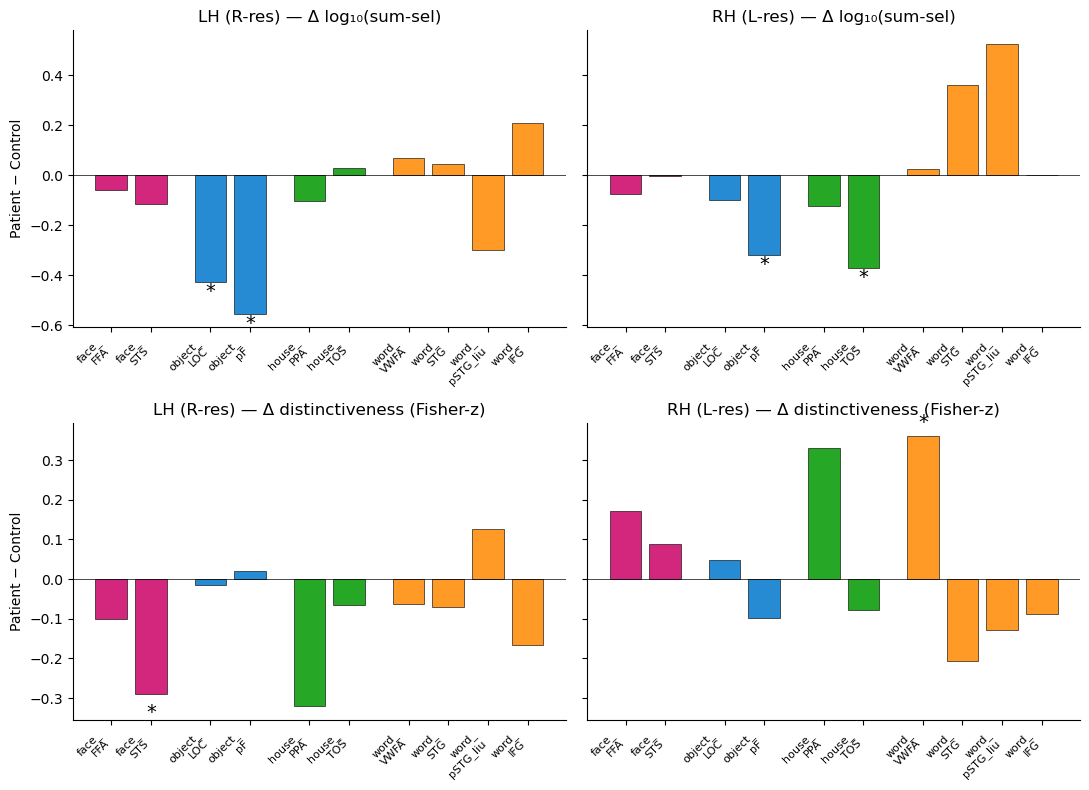

In [15]:
# --- Sub-ROI agreement plot: Δ per sub-ROI per category, by group, two measures ---
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharey='row')
for col_i, (intact, label) in enumerate([('l', 'LH (R-res)'), ('r', 'RH (L-res)')]):
    sub = agree_df[agree_df['group']==label]
    # Top row: Δ sum-sel
    ax = axes[0, col_i]
    xi = 0; xticks = []; xlabels = []
    for cat in CATS4:
        rois = CAT_SUBROIS[cat]
        for roi in rois:
            r = sub[sub['roi']==roi]
            if not len(r): xi += 1; continue
            d = r['d_sumsel'].iloc[0]
            p = r['p_sumsel'].iloc[0]
            ax.bar(xi, d, color=CAT_COLOR[cat], alpha=0.85, edgecolor='black', linewidth=0.5)
            if not np.isnan(p) and p < 0.05:
                ax.text(xi, d + (0.02 if d>0 else -0.06), '*', ha='center', fontsize=14)
            xticks.append(xi); xlabels.append(roi.replace('_', '_\n', 1))
            xi += 1
        xi += 0.5  # gap between categories
    ax.axhline(0, color='black', lw=0.5)
    ax.set_xticks(xticks); ax.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=8)
    ax.set_title(f'{label} — Δ log₁₀(sum-sel)')
    if col_i == 0: ax.set_ylabel('Patient − Control')
    # Bottom row: Δ distinctiveness
    ax = axes[1, col_i]
    xi = 0; xticks = []; xlabels = []
    for cat in CATS4:
        for roi in CAT_SUBROIS[cat]:
            r = sub[sub['roi']==roi]
            if not len(r): xi += 1; continue
            d = r['d_distinct'].iloc[0]
            p = r['p_distinct'].iloc[0]
            ax.bar(xi, d, color=CAT_COLOR[cat], alpha=0.85, edgecolor='black', linewidth=0.5)
            if not np.isnan(p) and p < 0.05:
                ax.text(xi, d + (0.02 if d>0 else -0.06), '*', ha='center', fontsize=14)
            xticks.append(xi); xlabels.append(roi.replace('_', '_\n', 1))
            xi += 1
        xi += 0.5
    ax.axhline(0, color='black', lw=0.5)
    ax.set_xticks(xticks); ax.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=8)
    ax.set_title(f'{label} — Δ distinctiveness (Fisher-z)')
    if col_i == 0: ax.set_ylabel('Patient − Control')
plt.tight_layout()
plt.savefig(FIG_DIR / 'subroi_agreement.png', dpi=200, bbox_inches='tight')
plt.show()

## 8. Proposal 6 — Hemisphere-symmetric prediction (gradient rank correlation)

**The single load-bearing test of the gradient hypothesis.**

Logic: graded specialization predicts that disruption magnitude rank-orders ROIs *differently* for LH-intact (R-resect) vs RH-intact (L-resect) patients. Lateralized categories should be more disrupted in the group that lost their dominant hemisphere; bilateral categories should show similar disruption in both groups. This produces a **negative** Spearman rank correlation across the two groups\' Δ rankings.

**Pre-registration (per user direction):** distinctiveness and sum-selectivity run as **co-primary** measures, no hierarchy.

**Two granularities:**
- **6a — Category-level** (4 ROIs): direct mapping to the theoretical claim. Sub-ROIs collapsed within category.
- **6b — Sub-ROI-level** (10 ROIs): more power; framed at category level via Section 7 sub-ROI agreement.

**Permutation null (most sensitive for gradient):** group labels (control/patient) shuffled within each side independently per unit; Δ_LH and Δ_RH recomputed; Spearman ρ recomputed. 10,000 iterations, seed 42. **Primary p is one-sided** for ρ < 0 (directional gradient prediction). Two-sided p reported alongside.

**Why one-sided + group-label null:** unit-identity null caps minimum p at 1/24 ≈ 0.042 with 4 units. Group-label null uses real subject variability. One-sided is justified by directional theoretical prediction.

**Power caveat:** with 4 (cat) and 10 (sub-ROI) units, rank correlation has limited power. A null result is *not* strong falsification at this N.

In [16]:
from tqdm.auto import tqdm

def compute_delta(ctrl_vals, pt_vals):
    """Mean(pt) - mean(ctrl), nan if either is empty/insufficient."""
    cv = np.asarray(ctrl_vals, float); cv = cv[~np.isnan(cv)]
    pv = np.asarray(pt_vals, float);   pv = pv[~np.isnan(pv)]
    if len(cv) < 3 or len(pv) < 2: return np.nan
    return pv.mean() - cv.mean()

def gather_unit_vals(unit, side, df, subjects, measure):
    """unit: ROI name (sub-ROI mode) or category name (category mode).
       side: 'l' or 'r'. measure: 'sum_sel' or 'distinct'.
       Returns array of one value per subject (mean across sub-ROIs if category mode, log10 for sum-sel)."""
    if measure == 'sum_sel':
        col = 'sum_selec_norm'
    elif measure == 'distinct':
        col = 'liu_distinctiveness'
    else:
        raise ValueError(measure)
    rois = CAT_SUBROIS[unit] if unit in CAT_SUBROIS else [unit]
    out = []
    for s in subjects:
        sd = df[(df['subject_id']==s) & (df['category'].isin(rois)) & (df['hemi']==side)]
        vals = sd[col].dropna().values
        if measure == 'sum_sel':
            vals = vals[vals > 0]
            if len(vals): out.append(np.mean(np.log10(vals)))
        else:
            if len(vals): out.append(np.mean(vals))
    return np.array(out)

def gradient_rank_test(units, measure, n_perm=N_PERM, seed=SEED, alternative='less', desc=''):
    """Compute Δ_LH and Δ_RH per unit; return Spearman ρ + permutation p.
    Permutation H0: group labels exchangeable within each side (group-label null).
    alternative='less' = one-sided test for ρ < 0 (gradient prediction: rank reversal).
    alternative='two-sided' = two-sided.
    Most sensitive to gradient prediction: 'less' (directional, group-label null with real variability)."""
    pt_subs_LH = [s for s in otc_subs if pt_intact_hemi(s) == 'l']
    pt_subs_RH = [s for s in otc_subs if pt_intact_hemi(s) == 'r']
    delta_LH, delta_RH = [], []
    perm_payload = []
    for unit in units:
        ct_L = gather_unit_vals(unit, 'l', ctrl_le, ctrl_subs, measure)
        pt_L = gather_unit_vals(unit, 'l', pt_le, pt_subs_LH, measure)
        ct_R = gather_unit_vals(unit, 'r', ctrl_le, ctrl_subs, measure)
        pt_R = gather_unit_vals(unit, 'r', pt_le, pt_subs_RH, measure)
        delta_LH.append(compute_delta(ct_L, pt_L))
        delta_RH.append(compute_delta(ct_R, pt_R))
        perm_payload.append((ct_L, pt_L, ct_R, pt_R))
    delta_LH = np.array(delta_LH); delta_RH = np.array(delta_RH)
    valid = ~(np.isnan(delta_LH) | np.isnan(delta_RH))
    if valid.sum() < 3:
        return {'units': list(units), 'delta_LH': delta_LH, 'delta_RH': delta_RH,
                'rho': np.nan, 'p_perm_one_sided': np.nan, 'p_perm_two_sided': np.nan,
                'n_units_valid': valid.sum(), 'alternative': alternative}
    rho_obs, _ = spearmanr(delta_LH[valid], delta_RH[valid])
    rng = np.random.RandomState(seed)
    null = np.empty(n_perm)
    for i in tqdm(range(n_perm), desc=desc, leave=False):
        d_LH_p = []; d_RH_p = []
        for ct_L, pt_L, ct_R, pt_R in perm_payload:
            n_pt_L = len(pt_L); n_pt_R = len(pt_R)
            if n_pt_L < 2 or len(ct_L) < 3 or n_pt_R < 2 or len(ct_R) < 3:
                d_LH_p.append(np.nan); d_RH_p.append(np.nan); continue
            pool_L = np.concatenate([ct_L, pt_L]); pool_R = np.concatenate([ct_R, pt_R])
            permL = rng.permutation(pool_L); permR = rng.permutation(pool_R)
            d_LH_p.append(permL[:n_pt_L].mean() - permL[n_pt_L:].mean())
            d_RH_p.append(permR[:n_pt_R].mean() - permR[n_pt_R:].mean())
        d_LH_p = np.array(d_LH_p); d_RH_p = np.array(d_RH_p)
        v = ~(np.isnan(d_LH_p) | np.isnan(d_RH_p))
        if v.sum() < 3:
            null[i] = np.nan
        else:
            null[i], _ = spearmanr(d_LH_p[v], d_RH_p[v])
    null = null[~np.isnan(null)]
    # One-sided p for ρ < 0 (gradient prediction)
    p_one = (null <= rho_obs).mean()
    # Two-sided p (equivalent to current)
    p_two = (np.abs(null) >= abs(rho_obs)).mean()
    return {'units': list(units), 'delta_LH': delta_LH, 'delta_RH': delta_RH,
            'rho': rho_obs, 'p_perm_one_sided': p_one, 'p_perm_two_sided': p_two,
            'n_units_valid': valid.sum(), 'n_perm_valid': len(null),
            'null_distribution': null, 'alternative': alternative}

In [17]:
# --- 6a: Category-level (4 ROIs) — co-primary measures ---
# Primary p: one-sided (ρ < 0, gradient prediction). Two-sided also reported.
print('=== Proposal 6a — Category-level gradient rank correlation (4 ROIs) ===\n')
cat_results = {}
for measure in ['sum_sel', 'distinct']:
    res = gradient_rank_test(CATS4, measure, desc=f'cat-{measure}')
    cat_results[measure] = res
    print(f'\nMeasure: {measure}')
    print(f'  {"Category":10s} {"Δ_LH-intact":>14s} {"Δ_RH-intact":>14s}')
    for u, dL, dR in zip(res['units'], res['delta_LH'], res['delta_RH']):
        print(f'  {u:10s} {dL:>+14.4f} {dR:>+14.4f}')
    print(f'  Spearman ρ = {res["rho"]:+.3f}')
    print(f'  p one-sided (ρ<0, gradient)  = {res["p_perm_one_sided"]:.4f}  ← primary')
    print(f'  p two-sided                  = {res["p_perm_two_sided"]:.4f}')
    print(f'  n_units = {res["n_units_valid"]}, n_perm valid = {res.get("n_perm_valid","NA")}')
    print(f'  {"✓ supports" if res["rho"] < 0 else "✗ does not support"} gradient prediction (sign).')

=== Proposal 6a — Category-level gradient rank correlation (4 ROIs) ===



cat-sum_sel:   0%|          | 0/10000 [00:00<?, ?it/s]


Measure: sum_sel
  Category      Δ_LH-intact    Δ_RH-intact
  face              -0.0909        -0.0231
  object            -0.4903        -0.2072
  house             -0.0351        -0.2478
  word              -0.0587        +0.3943
  Spearman ρ = -0.200
  p one-sided (ρ<0, gradient)  = 0.4603  ← primary
  p two-sided                  = 0.9218
  n_units = 4, n_perm valid = 10000
  ✓ supports gradient prediction (sign).


cat-distinct:   0%|          | 0/10000 [00:00<?, ?it/s]


Measure: distinct
  Category      Δ_LH-intact    Δ_RH-intact
  face              -0.1953        +0.1337
  object            +0.0022        -0.0197
  house             -0.1932        +0.1261
  word              -0.0429        -0.0187
  Spearman ρ = -1.000
  p one-sided (ρ<0, gradient)  = 0.0449  ← primary
  p two-sided                  = 0.0905
  n_units = 4, n_perm valid = 10000
  ✓ supports gradient prediction (sign).


In [18]:
# --- 6b: Sub-ROI-level (10 ROIs) — co-primary measures ---
print('=== Proposal 6b — Sub-ROI-level gradient rank correlation ===\n')
subroi_results = {}
for measure in ['sum_sel', 'distinct']:
    res = gradient_rank_test(ALL_SUBROIS, measure, desc=f'subroi-{measure}')
    subroi_results[measure] = res
    print(f'\nMeasure: {measure}  ({len(ALL_SUBROIS)} sub-ROIs)')
    print(f'  {"Sub-ROI":18s} {"Δ_LH-intact":>14s} {"Δ_RH-intact":>14s}')
    for u, dL, dR in zip(res['units'], res['delta_LH'], res['delta_RH']):
        print(f'  {u:18s} {dL:>+14.4f} {dR:>+14.4f}')
    print(f'  Spearman ρ = {res["rho"]:+.3f}')
    print(f'  p one-sided (ρ<0, gradient)  = {res["p_perm_one_sided"]:.4f}  ← primary')
    print(f'  p two-sided                  = {res["p_perm_two_sided"]:.4f}')
    print(f'  n_units = {res["n_units_valid"]}, n_perm valid = {res.get("n_perm_valid","NA")}')
    print(f'  {"✓ supports" if res["rho"] < 0 else "✗ does not support"} gradient prediction (sign).')

=== Proposal 6b — Sub-ROI-level gradient rank correlation ===



subroi-sum_sel:   0%|          | 0/10000 [00:00<?, ?it/s]


Measure: sum_sel  (10 sub-ROIs)
  Sub-ROI               Δ_LH-intact    Δ_RH-intact
  face_FFA                  -0.0603        -0.0759
  face_STS                  -0.1167        -0.0013
  house_PPA                 -0.1009        -0.1243
  house_TOS                 +0.0307        -0.3713
  object_LOC                -0.4272        -0.0996
  object_pF                 -0.5533        -0.3175
  word_VWFA                 +0.0698        +0.0266
  word_STG                  +0.0449        +0.3629
  word_pSTG_liu             -0.2978        +0.5267
  word_IFG                  +0.2088        +0.0013
  Spearman ρ = +0.333
  p one-sided (ρ<0, gradient)  = 0.8208  ← primary
  p two-sided                  = 0.3791
  n_units = 10, n_perm valid = 10000
  ✗ does not support gradient prediction (sign).


subroi-distinct:   0%|          | 0/10000 [00:00<?, ?it/s]


Measure: distinct  (10 sub-ROIs)
  Sub-ROI               Δ_LH-intact    Δ_RH-intact
  face_FFA                  -0.1016        +0.1708
  face_STS                  -0.2889        +0.0895
  house_PPA                 -0.3200        +0.3308
  house_TOS                 -0.0664        -0.0786
  object_LOC                -0.0158        +0.0475
  object_pF                 +0.0201        -0.0976
  word_VWFA                 -0.0624        +0.3601
  word_STG                  -0.0709        -0.2065
  word_pSTG_liu             +0.1266        -0.1289
  word_IFG                  -0.1671        -0.0891
  Spearman ρ = -0.430
  p one-sided (ρ<0, gradient)  = 0.1102  ← primary
  p two-sided                  = 0.2269
  n_units = 10, n_perm valid = 10000
  ✓ supports gradient prediction (sign).


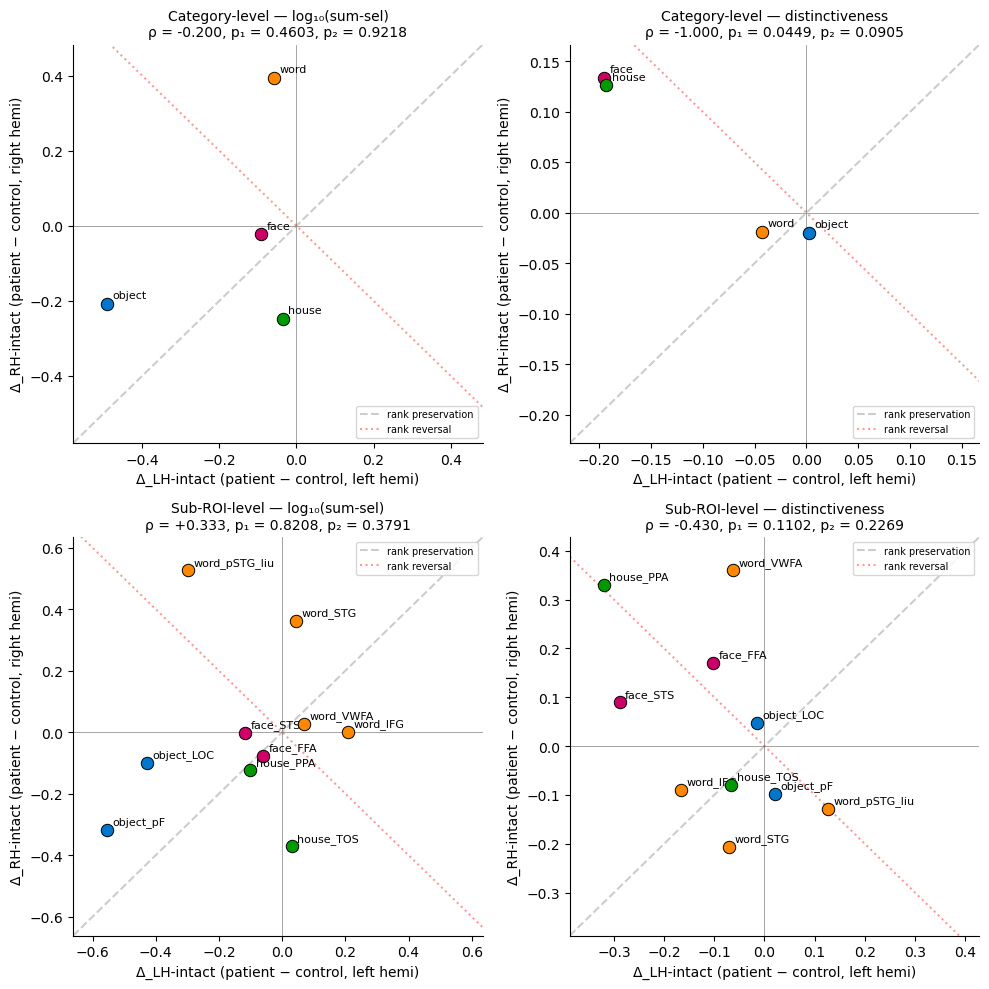

In [19]:
# --- Visualization: Δ_LH vs Δ_RH scatter, both granularities, both measures ---
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
panels = [
    (axes[0,0], cat_results['sum_sel'],     'Category-level — log₁₀(sum-sel)'),
    (axes[0,1], cat_results['distinct'],    'Category-level — distinctiveness'),
    (axes[1,0], subroi_results['sum_sel'],  'Sub-ROI-level — log₁₀(sum-sel)'),
    (axes[1,1], subroi_results['distinct'], 'Sub-ROI-level — distinctiveness'),
]
for ax, res, title in panels:
    units = res['units']; dL = res['delta_LH']; dR = res['delta_RH']
    for u, x, y in zip(units, dL, dR):
        if np.isnan(x) or np.isnan(y): continue
        cat = u if u in CAT_COLOR else u.split('_')[0]
        ax.scatter(x, y, s=80, color=CAT_COLOR.get(cat, 'gray'),
                   edgecolors='black', linewidth=0.7, zorder=5)
        ax.annotate(u, (x, y), xytext=(4, 4), textcoords='offset points', fontsize=8)
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
    finite_d = np.concatenate([dL[~np.isnan(dL)], dR[~np.isnan(dR)]])
    if len(finite_d):
        lims = [finite_d.min(), finite_d.max()]
        pad = 0.1 * (lims[1] - lims[0]) if lims[1] > lims[0] else 0.1
        lims = [lims[0]-pad, lims[1]+pad]
        ax.plot(lims, lims, '--', color='gray', alpha=0.4, label='rank preservation')
        ax.plot(lims, [-l for l in lims], ':', color='red', alpha=0.4, label='rank reversal')
        ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Δ_LH-intact (patient − control, left hemi)')
    ax.set_ylabel('Δ_RH-intact (patient − control, right hemi)')
    ax.set_title(f'{title}\nρ = {res["rho"]:+.3f}, p₁ = {res["p_perm_one_sided"]:.4f}, p₂ = {res["p_perm_two_sided"]:.4f}',
                 fontsize=10)
    ax.legend(loc='best', fontsize=7)
plt.tight_layout()
plt.savefig(FIG_DIR / 'gradient_rank_correlation.png', dpi=200, bbox_inches='tight')
plt.show()

## 9. Summary table

Compact summary of the gradient test (Proposal 6) across granularities × measures, plus pointers to the supporting analyses.

In [20]:
summary_rows = []
for label, results in [('Category-level (4 units)', cat_results),
                       ('Sub-ROI-level (10 units)', subroi_results)]:
    for measure, res in results.items():
        summary_rows.append({'granularity': label, 'measure': measure,
                             'n_units': res['n_units_valid'],
                             'spearman_rho': res['rho'],
                             'p_one_sided_primary': res['p_perm_one_sided'],
                             'p_two_sided': res['p_perm_two_sided'],
                             'predicted_direction': 'negative (rank reversal)',
                             'sign_supports': bool(res['rho'] < 0) if not np.isnan(res['rho']) else None})
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(FIG_DIR / 'gradient_test_summary.csv', index=False)
print(summary_df.to_string(index=False))

print('\nFiles written to:', FIG_DIR)
for f in sorted(FIG_DIR.glob('*')):
    print(f'  {f.name}')

             granularity  measure  n_units  spearman_rho  p_one_sided_primary  p_two_sided      predicted_direction  sign_supports
Category-level (4 units)  sum_sel        4     -0.200000               0.4603       0.9218 negative (rank reversal)           True
Category-level (4 units) distinct        4     -1.000000               0.0449       0.0905 negative (rank reversal)           True
Sub-ROI-level (10 units)  sum_sel       10      0.333333               0.8208       0.3791 negative (rank reversal)          False
Sub-ROI-level (10 units) distinct       10     -0.430303               0.1102       0.2269 negative (rank reversal)           True

Files written to: /user_data/csimmon2/git_repos/sym_pt/C_results/figures/gradient_testing
  control_LI_by_category.png
  control_LI_per_subject.csv
  decomposition_partial.csv
  gradient_rank_correlation.png
  gradient_test_summary.csv
  rank_preservation_proxy.csv
  rank_preservation_proxy.png
  subroi_agreement.csv
  subroi_agreement.png


## 10. Open issues / next steps

Honest list of what this notebook *does not* settle:

1. **Proposal 1 (LI literature comparison).** `LIT_VALUES` is placeholder. Extract Behrmann & Plaut 2020 and Nordt 2023 LI numbers and re-run Section 4 cell 2.
2. **Proposal 3 (rank-order on response magnitude).** Implemented as RDM-based proxy. The literal magnitude test requires per-condition betas extracted within each ROI mask — would need a new pipeline pass over cope volumes 15–18 (raw category copes per Liu).
3. **Proposal 4 (within/between decomposition).** Limited to between-category-only partial decomposition because within-category split-half values aren't in the merged CSV. To do this properly: locate `pairwise_correlations_*.csv` in `/group_results/liu_distinctiveness/`, confirm whether it stores within-category split-half r values, and implement the proper within−between decomposition cell.
4. **Power on Proposal 6.** With 4 (cat) and 10 (sub-ROI) units, rank correlation is underpowered. A null does not strongly falsify. The category-level test (4 units) is closer to the theoretical claim but more underpowered; the sub-ROI test (10 units) has more power but treats sub-ROIs as if independent (they aren't, fully). Bridging via Section 7 sub-ROI agreement is the honest framing.
5. **Hemi vs side framing.** The current Δ definition compares patient intact-hemi values to control same-hemi values. This is the cleanest within-hemi comparison but means "disruption" mixes loss of resected-side input *and* reorganization within the intact side. Worth being explicit about in any write-up.